In [4]:
# Use webbrowser to launch a browser from Python
import webbrowser
import json

from stravalib.client import Client

In [5]:
from stravalib import Client

with open("client_secrets.txt", "r") as f:
    client_id, client_secret = f.read().strip().split(",")
client = Client()

ERROR:root:Please make sure your STRAVA_CLIENT_ID is set in your environment.


In [58]:
client_id,client_secret

('158518', 'aa3e37951305808571c9184931dec6d7f76e9be3')

In [6]:
# Create a localhost URL
redirect_url = "http://127.0.0.1:5000/authorization"
# Define a read-only scope
request_scope = ["read_all", "profile:read_all", "activity:read_all"]

# Create an authorization URL using stravalib
url = client.authorization_url(
    client_id=client_id,
    redirect_uri=redirect_url,
    scope=request_scope,
)

In [60]:
print(url)

https://www.strava.com/oauth/authorize?client_id=158518&redirect_uri=http%3A%2F%2F127.0.0.1%3A5000%2Fauthorization&approval_prompt=auto&scope=read_all%2Cprofile%3Aread_all%2Cactivity%3Aread_all&response_type=code


In [7]:
# Open the url that you created above in a web browser
webbrowser.open(url)
print(
    """You will see a URL that looks like this:
    http://127.0.0.1:5000/authorization?state=&code=12323423423423423423423550&scope=read,activity:read_all,profile:read_all,read_all
    Copy the values between code= and & in the URL that you see in the browser."""
)
# Using input allows you to copy the code into your Python console (or Jupyter Notebook)
code = input("Please enter the code that you received: ")

print(
    f"Great! Your code is {code}\n"
    "Next, I will exchange that code for a token.\n"
    "I only have to do this once."
)

You will see a URL that looks like this:
    http://127.0.0.1:5000/authorization?state=&code=12323423423423423423423550&scope=read,activity:read_all,profile:read_all,read_all
    Copy the values between code= and & in the URL that you see in the browser.
Great! Your code is bef08553b47ed057b019befb01cdd3f46fd4006a
Next, I will exchange that code for a token.
I only have to do this once.


In [8]:
token_response = client.exchange_code_for_token(
    client_id=client_id, client_secret=client_secret, code=code
)

# Save the token response as a JSON file
with open("/Users/elias/Desktop/Random/strava_api_test/token.json", "w") as f:
    json.dump(token_response, f)

print("Token saved - hooray!")

# Access and refresh tokens
access_token = token_response["access_token"]
refresh_token = token_response["refresh_token"]  # Use this after 6 hours


Token saved - hooray!


In [9]:
# Open the token JSON file that you saved earlier
with open("/Users/elias/Desktop/Random/strava_api_test/token.json", "r") as f:
    token_response_refresh = json.load(f)

print(token_response_refresh)

# Output:
# {'access_token': 'ab0667a99d17b7c278d9f730f733ad09016306cf',
# 'refresh_token':  '9f8d5689c93e83c7b0c69a8585010d4762e8b2ac',
#  'expires_at': 1726560054}

{'access_token': '16755dae1f3441ecbd58d93fee014768f6139e05', 'refresh_token': '9730a68f8a2b8fde259b4551ef2bc4dfdd9aa47d', 'expires_at': 1746680286}


In [10]:
refresh_response = client.refresh_access_token(
    client_id=client_id,  # Stored in the secrets.txt file above
    client_secret=client_secret,
    refresh_token=refresh_token,  # Stored in your JSON file
)

# Check that the refresh worked
client.get_athlete()

# View the newly refreshed token
print(client.access_token)

16755dae1f3441ecbd58d93fee014768f6139e05


<BatchedResultsIterator entity=SummaryActivity>
Activity number 0: root='Run'
activity.average_speed: 2.909
activity.start_date: 2025-01-19 06:32:52+00:00
activity.kudos_count: 13
Activity number 1: root='Run'
activity.average_speed: 2.751
activity.start_date: 2025-03-15 12:22:34+00:00
activity.kudos_count: 12
Activity number 2: root='Run'
activity.average_speed: 2.955
activity.start_date: 2025-03-18 20:21:35+00:00
activity.kudos_count: 8
Activity number 3: root='Run'
activity.average_speed: 2.691
activity.start_date: 2025-03-22 21:51:54+00:00
activity.kudos_count: 8
Activity number 4: root='Run'
activity.average_speed: 2.899
activity.start_date: 2025-03-27 15:59:54+00:00
activity.kudos_count: 6
Activity number 5: root='Run'
activity.average_speed: 2.943
activity.start_date: 2025-03-30 17:39:06+00:00
activity.kudos_count: 8
Activity number 6: root='Run'
activity.average_speed: 2.908
activity.start_date: 2025-04-06 16:50:42+00:00
activity.kudos_count: 9
Activity number 7: root='Run'
act

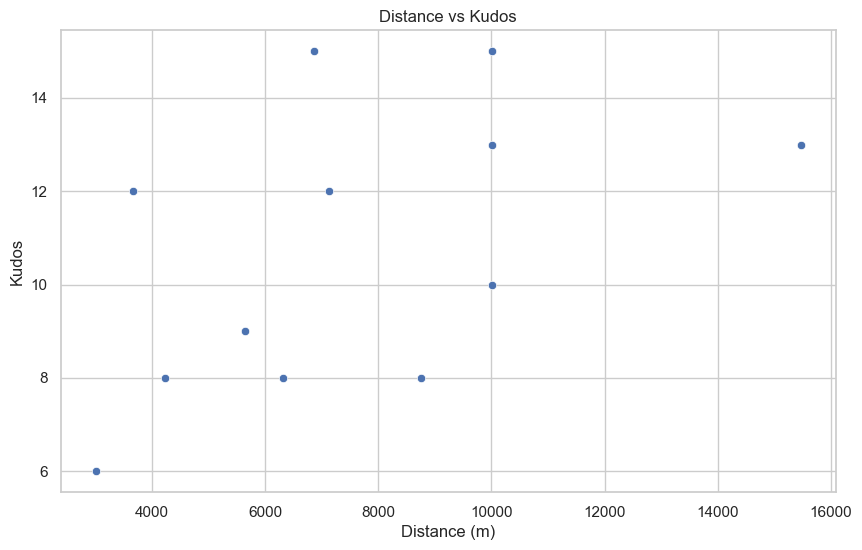

Correlation between distance and kudos: 0.5016896162867136


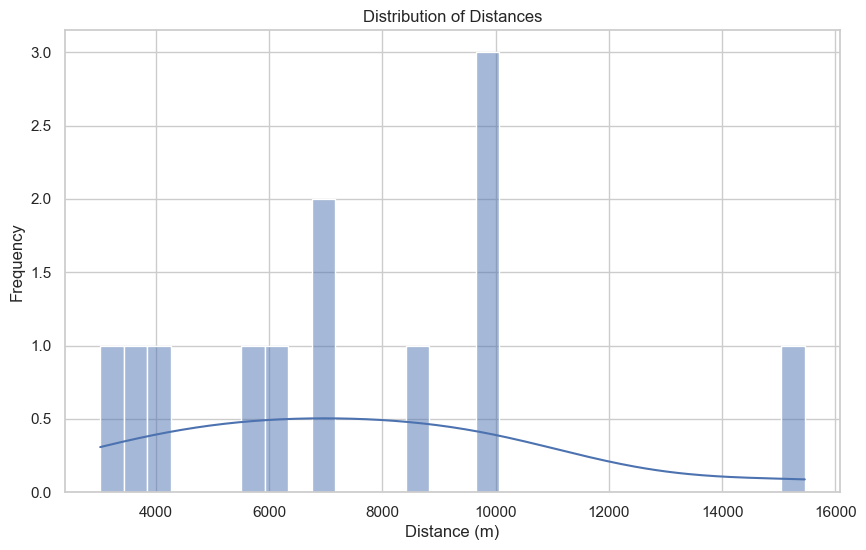

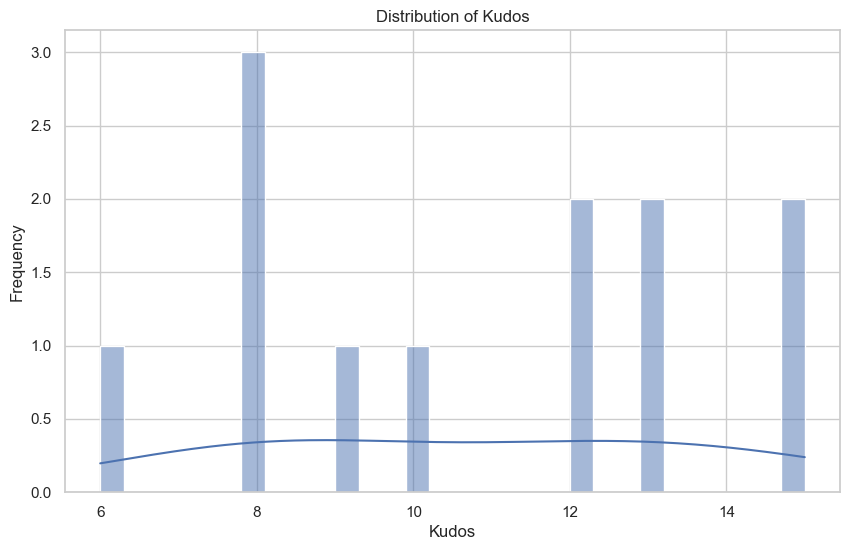

In [12]:
activities = client.get_activities(after="2025-01-01")
print(activities)
for i, activity in enumerate(activities):
    print(f"Activity number {i}: {activity.type}")
    print(f"activity.average_speed: {activity.average_speed}")
    print(f"activity.start_date: {activity.start_date}")
    print(f"activity.kudos_count: {activity.kudos_count}")

# does distance and number of kudos correlate?
distances = []
kudos = []
for i, activity in enumerate(activities):
    distances.append(activity.distance)
    kudos.append(activity.kudos_count)

# Plot the data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Set the style
sns.set_theme(style="whitegrid")
# Create a DataFrame
df = pd.DataFrame({"distance": distances, "kudos": kudos})
# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="distance", y="kudos")
plt.title("Distance vs Kudos")
plt.xlabel("Distance (m)")
plt.ylabel("Kudos")
plt.show()
# Calculate the correlation
correlation = df["distance"].corr(df["kudos"])
print(f"Correlation between distance and kudos: {correlation}")
# Create a histogram of the distances
plt.figure(figsize=(10, 6))
sns.histplot(df["distance"], bins=30, kde=True)
plt.title("Distribution of Distances")
plt.xlabel("Distance (m)")
plt.ylabel("Frequency")
plt.show()
# Create a histogram of the kudos
plt.figure(figsize=(10, 6))
sns.histplot(df["kudos"], bins=30, kde=True)
plt.title("Distribution of Kudos")
plt.xlabel("Kudos")
plt.ylabel("Frequency")
plt.show()

<class 'stravalib.model.Map'>
_yvdH{gweAg@?GUq@_@cACU_@m@AMeAg@WOYg@V}BtDSr@w@r@gAdCoBvCk@d@yBvD{@z@W`A}B_AeDuBmAeAEQuBsAO[GDgDaCu@gAI}@q@i@I_@QFc@k@[Gc@Tc@`Ac@~DkArIsBwDs@sBeAkAeAeCc@]e@_A}D{CgEsAyAq@Q\gBlKBVcArJ_AnHUf@Fd@]jCQ`@@x@a@xBIdBMd@YWQBO^m@zCWxC{@`AWzAyBgA[o@]?uC{@s@_@wAaAe@GuCKmBR{@W{B\wA`@_@c@A_AO?NQFkAQ_C{@qBiAeAo@IcBeCoB}A_@i@iA{CaByAwCeAYWUk@s@m@wEm@iAb@w@r@{@JkDWCOsAa@cA_B}@{@eAkBmDm@}BkC[IwCuCu@iA[}@@U[o@wAeBkAmA[}ANuA\kAh@cA~@aDr@_A\XFKkAwEw@qBQu@GeBZm@C[w@mAoA]aAu@}Be@q@_@sAkBi@UO_AWa@@]S_@i@]iAmA[m@oBo@a@_AKu@_@c@qBkAmCgDc@GUn@@p@fAtCz@f@xACb@XnAvClAr@d@`Cn@^jAQb@LPnAv@|BHtA?~BLz@f@nAlEf@rAn@r@Gz@b@l@d@b@t@bCrH`CG`Ac@t@FVHjB~BzCjBfCi@`Bp@vBfD~@nBVbA@d@LLCVd@tAXrD`@~Ab@nAtBxCnBx@vBIhA\~ELxA^n@Dj@_@lBa@l@V~BAh@R`G|DzFdCzAjAl@r@hAtBl@hBVnCEyBzAcAnDp@`C@l@\n@x@}BoGY{BqByEoAgBeB{@oAMyBVmBjAIf@J\fDdEbCtHz@WnCh@`BA~A^h@t@o@cAUKkDEoBk@cAZkBpBa@LJi@f@IrAoAp@UnCp@j@K~@RpAYdALJW?i@Pa@p@G\mAEi@`@}APMCg@PwBr@sDAwAZoAAa@LaAJK?o@`@_CAaARg@fGjB~EtDdAvAV~@rAlBT|@zA`Cj@|Ah@p@JG@[l@_@

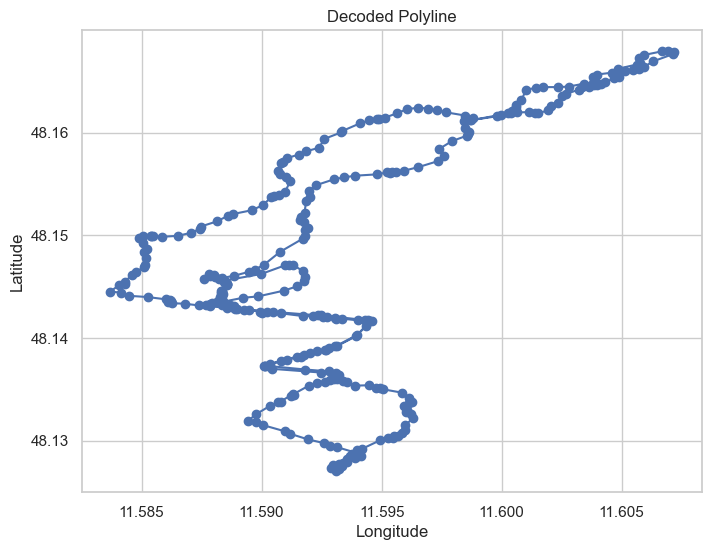

<class 'stravalib.model.Map'>
hnekFdca{JKSKGM[IKCYI_@AU@gCI_@Oc@ASEEGUMmAGM?GIEKy@ESKQ?OCCEWK]KOCIIMMMOWQOQWGAGGCI?S@ENQCC_B[a@CYCEGYAo@JUA[B{@VS@K?SKS?GJGDS`@Kb@Of@CV?HBBCd@DVAL?ZDb@Ab@Hb@FL?j@DPAVFPV^b@TLN\J`@BJAP@FAZB^GPBRIHATS^KDEt@]L?HEH@PEd@Ap@IRRNFFFFHRb@Jd@@\Ch@QRYD_@@UEQAI@QEOJGCO@EBI@MHYBq@V_Ap@IB[PE@_@Pe@JGFSBG?KCGBACUBmAMMCGICDEE]CQMWIs@a@][e@[MYc@k@Ig@Uc@Wq@YaAEWO]Ky@GKEs@@YEa@?[Da@AMH_@DI?ODSZoARUDMXSNQn@c@PEJEFIDAHDVBHDPTTRLXPRFAHBLPLFRPXJNLFJFDN?HCHBLEB@`@GFEF@PGFBFAVK`@B\Ad@JBA|@Hb@RTDr@`@P@JAVHd@?JAN@DAL@DCHMJCDBL?PED@BE`@GBCNAXKD@DEh@APIN?LGZEDA@GH?LKFAD?FGRIDBVIPALKl@K@EHCFG`@OZYHC@EPMHKZM\QHCVKHI


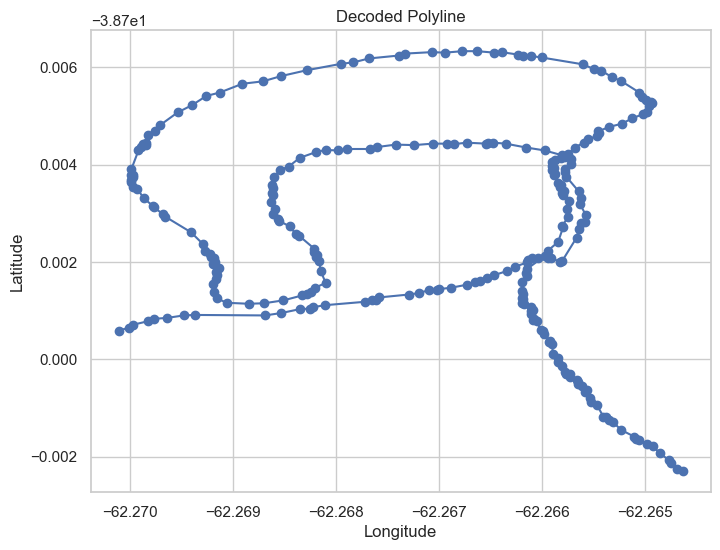

<class 'stravalib.model.Map'>
vuekFrfa{JOAIEU?m@MOKSAiAYWWCCM?CEM]MQI_@AUGSAOIYC_@DK?I?e@CMDWAa@MY?KCMGE?]CIAUOw@AQCE?SCO@G@a@CSG[GMKk@ICIYKEIOIEGYUe@MCIFGCKMAGBAEESGSS]AGGWACEGDKGM?OBOIo@AKEWJYEMJ]FE?OHIPQRGNIDCBE?IRa@j@Ul@?TG^@REn@FRCRLt@AFHRA^BF?JH`@JHDJPDDD^PH@JHR@TFHAJBJGDDPCH@RED@HCNAFBPGHG\OREHIJAVKBEv@OF@JCN?JCFBJGP@`@JJHRFDFHRCDBJBp@D^Oh@GBGFIBgAKs@EGBIAQDWLI?a@PQCSPAH[HqA|@O@GJGBMBO?ODMAEAKFi@?IDGFGZGHSBCHc@NEFK@IBAFQLGF?f@IABEBQGu@@[Ig@Ok@MSMEEE@YISWSIQMKQYKE]}@GAMIMcAKIGYMUG_@[_A@EG_@IMCI?UBOCU@E?q@Fo@CE@KBIFIFUAGDSCO@GZm@@QBANWRIPQDCHKVKL@DI^QD?h@PH?NHb@n@d@RDAAF?EBAJJFPAZBPCHAj@Ih@?l@ED@FAJFbAAJDD?HDP?LJVBRCf@B`AVf@x@n@XBPFb@@RDFCRAl@@LENIJKDKBi@BIVORk@?g@Ia@SYQGSOE@OCODMAe@DEBQCKBQ?SFQ@IDYj@AJCL@j@BJPd@ZPZBHCT?`@GR@PGN?JFTGRMLSJSBYBEEg@K]MUKIa@G_@?SBIDKAUDK?GCQFO@ECMJ_@d@El@?VBNFRHFBJHHt@JTIDDF?\Id@AJ@RGd@YF_@HQ@SCQ@ECUECM[UQUCc@@c@HECSFI?IBMAYF]NGHMVGf@BVH`@PXXLNBb@CZ?JCRAHCD@RKPCXKPOJSFk@A[EGAQKQWO_@CQ?ODUAEBO?EBICE@E?a@HYDMLORIV@LCJDh@Rd@NJ\FP?JEH@DC^CD@TGJBTI^GLO@EHG

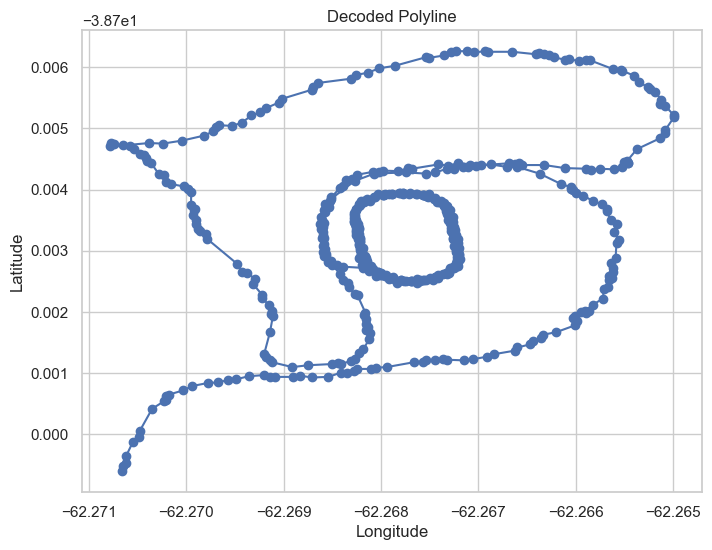

<class 'stravalib.model.Map'>
bsfkF~~a{JGAGGGAOMQEOUUKGKUKEIE@CCGMEUUQCUYQKc@W[KSI]GIEUKOCIo@w@O]BEIOSSMIASIEUUK]EGIg@Qo@Ia@@QDMEE?IIIAGO_@@MCEQFCAQLI@SL]LKJAFa@FIJI?MFSPE@MLE?KHQMIQIGYHUCQUQIU?CEc@CQIOCKEe@GMEMK_@ASIIFI?CEg@Oa@e@AKSYO]?IGGCIQU[S}@YIGUCa@SM?k@NQEUHGHQB[LMd@?ROVSt@UpB@DHe@HOAGFE@SPYHW?SGMECAEEEO?y@TI?IFK@IFc@@IBUCQLk@?[IOKg@IGGW?a@GaAi@EGSK]e@OGU]YYOYK]Ui@IYEEE]QYAUK]Ek@@MGMCe@GM@SMi@@[BICWHu@?KDSBIFm@DI@IDGBID??GBCDOJOPOBIPILQNMd@SNAHE\ABDR?\JJNF@DJTRBFJL@F\PNNXNPRNFDFNDd@?HALIZ@PGP@JE^BRIZ@FAJBNAJF\BLHF?XJJ@b@NTPR@PFH?TDBBTEVDXEV@VIN?HILCJGN@TGH@NGb@GLGJFV?VJBDFT\~@DDTd@Tl@?JPRNj@H?BDNb@FDLt@JFPED@DFFAHIf@HBHFF@JFDFv@NH@TDF?PFTDD@LD@BTNZBVNR?HDN@JRP@LHLNLFPDHDXCR@HFRLHBF@LHPDRBF?PDx@LBDb@DHBRDRFHF`@?LBJFDFPPFTb@Rd@PHBNJL?FD@FF@HDBDF@RDHLBDH?ZHPRNHTF@RXHH`@z@BLRVPNLDHPTNJ@VTBHHB


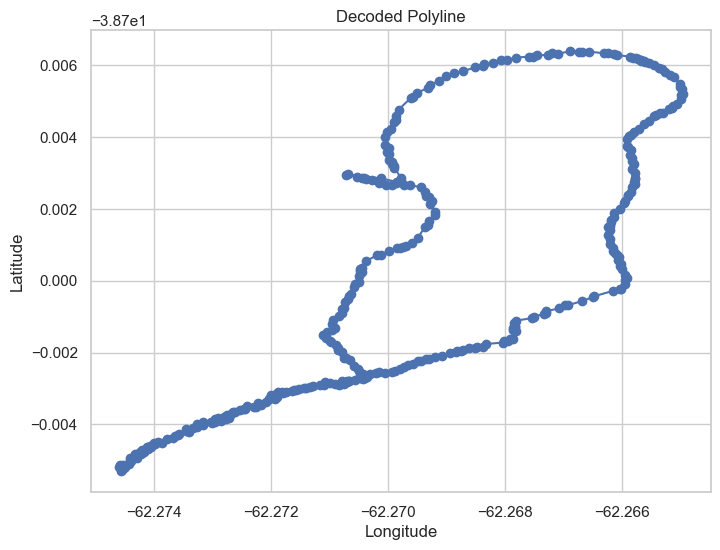

<class 'stravalib.model.Map'>
rsfkFz_b{JKKI?MIMSWQKQa@UCIOESUSOGQASEGQKAIKGUc@OME[AUGSYc@KUGCKMy@mAGEIYU_@AI]y@I_@?GGEOi@BYAKGME]GEKQAOCGIEE@UHYNILWHMNE?q@PSLEJ[NSE?CGBB??BEIm@MMGSAK@WECEE?OIKAGECEQ@SEc@Ok@GWMYEG@WEk@a@KC?EQYEQQUUm@k@i@OCWMMOWBs@QGBEAIDO?MJQBEFE?CI?]Ie@AGGG


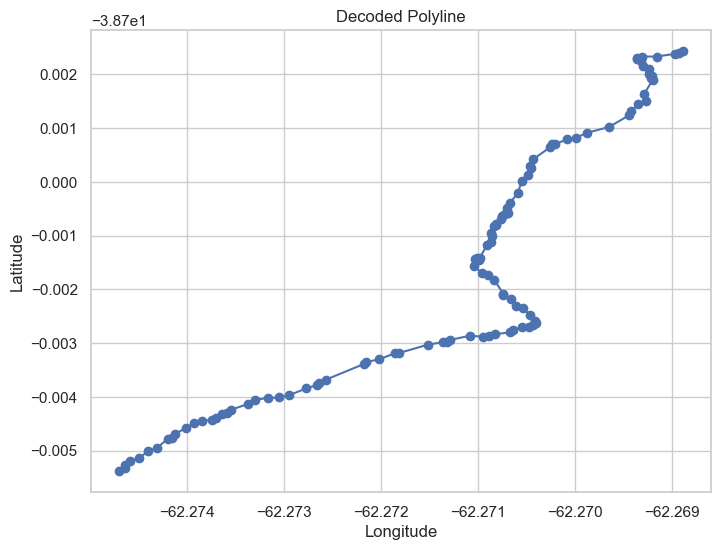

<class 'stravalib.model.Map'>
rkfkF~va{JOUA]KKYu@Y[MAISOOKOCYYQCI@GKGMSKg@GAIg@Uk@C{@K]AYM_@UGMBy@d@MAWLoAz@k@PIYGEMWK_@AGQYASIKIUA[M]IK[OAOIGCUMKDICO_@g@CKG?GKMe@YI[?s@Xk@?_A[AISQIUUWOkAMg@DMGM@c@GSBEAQCSIQAk@IKE]i@s@QKYe@OGc@e@kBk@w@K{BLQBcA~@K@e@`@OF[p@Ad@EDBTNd@A\FLB^GTRf@GVHx@h@j@\VPBXTvANb@Av@QTMTCTSJCLOXEDId@M`ABZKh@XV`@PhACf@U^s@ZMBuAMEDqAPIDIHUHYLm@`@AF[JGH[JS?GJuAPUGm@CSOo@KWAu@W}@e@[a@WO_@i@?EGGYq@[_BS_@G]M]AQQ]@OUeBA_AF_ANkAVw@n@{@HCj@i@XKt@e@dAHDJr@t@HLVJ^ZJVx@h@f@CPIb@@jAUd@?r@JZCVLj@Dl@\l@|@Lb@^n@Fv@JTE^Fv@?ZWn@WJk@Bu@?i@La@TI?o@VWN{ATqAC}@UWOQ_@@w@HYN_@l@o@XQpAa@v@Mb@@d@KJBXCRHV@`@JJLRBPLJ@`Av@L\@LE^a@R{@DICk@Fs@\a@Ng@HQPU@_@Nk@BkAKcAYYYG[B]J[?MJ]P[r@g@D@p@[j@G^MZB`AEPMVJj@Dj@Rb@Rx@p@Tn@ARBLELOL_@FIEMFu@AIFO?u@V[VYFy@Zk@Ho@CUDu@Ws@c@S]Ca@Fe@b@aAn@e@n@UXCtB[n@?zAVn@Zf@\HLf@^Dl@ERQLmAFu@F_@Jq@b@cAZKJY@OFaBGe@Om@i@K[DQ@w@Ha@Ta@d@a@h@[T@r@O`@EjAA^FZCXHJJ^JRBr@h@b@j@FP@TEb@SJyAE}@Tc@TEEQR[FONUBkAXUGMDo@Kw@e@I?OUEc@Bq@Li@Zg@ZY~@_@vASbBAzA`@x@^|@r@JTBZGd@SJ]IKDk@BeANOPWFEC]Vc@

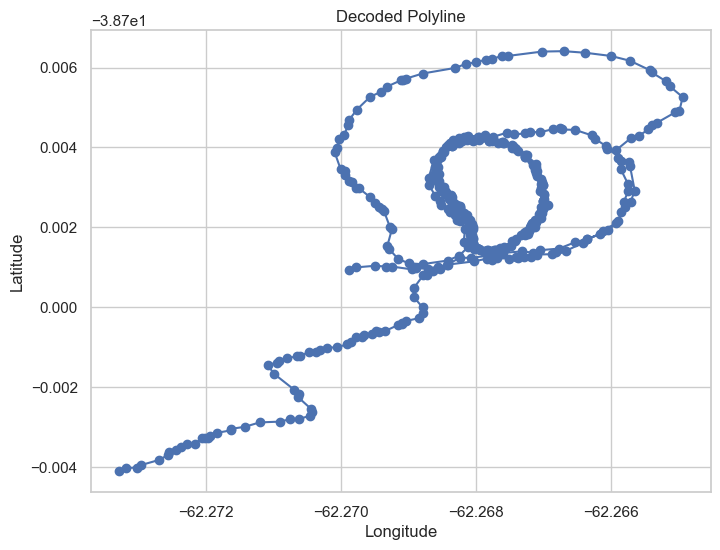

<class 'stravalib.model.Map'>
drfkFp~a{JOSKCCGw@g@GGCIi@e@CKGGWc@Sc@AE_@i@CMMQAQOUK[[k@U[GCGUMWGIKEMWEQMUI_@CCO]E_@KQA[CECWCG@GKYE]Q?OLI?e@Xg@\YNI@KHODOJa@RMSKI_@C]QWBICCEa@KE@IIS@WKQMQ?MEIBIA]MUOGDc@OMBy@u@Ui@GGSm@AKDSCM@OCQ@SOq@B_@G]OSQc@KMUGCGUQM@CCKAi@?EBSAQHOBIHE@I?QGKBYGAGPOFODa@G]GKEYEIYUM@GAU@]FMCKDIAEDK?IEm@J_@`@ANKX?b@DVLb@NHDJTFXEHDTITAH@XIR@HIF@b@[LYHg@Ce@Ma@SUOIe@A]DWAMDcAPWRUl@Er@JPH`@h@ZNCB@ZGJBNCJBLANGF@HGV?\WHMDUBCDOA_AQg@GEMCOG_@BM?CCI@ID_@@GDS@EBUCMBWTM^EFCX@h@FTFH?FJNXHJ?DBPET@NCD@DAX?FEN@@BDEZMFEFCLOTi@Ba@CWMa@QQUM]CU@IEEDCCKFK?EBGAYDE?[BMFQNUp@Aj@Hd@DJ`@\NDJ?NANEDBPEJBNCDGNAF@DBFERB@IHANOTe@AeAKa@MS_@SI?c@DWAMD]?q@TEFODMPI\CX@`@HXZ^FJRFP?^EHCNALIH?D@RAh@OX[JW@}@Wq@MQOMQCS@SHSCi@NS?QFO?UVMREPG^@h@DDBLHPVNH@LJTGDBf@En@QHBNCf@YHMLa@@UEc@I[MM?G[OIC]BICQFSAID[?s@RSVSj@AJB^?PNb@HJNDD?NFb@A^IbAGj@MLK@KJU@WIeAKWECEGUKQAo@HY@EBGAIBS?]FSJSTGJGf@?RHj@PX@Hf@N\KP@NCF?PEZ?d@IHMRAN_@DQ?UCICWMo@USUIk@DIAGFi@BUFG?YH]VMRIl@Bf@Xh@j@P\?LCX?FCP@JERAFBPGVCLBHAL@JLL@RCJOLBFC\?JEF@HCF?BD

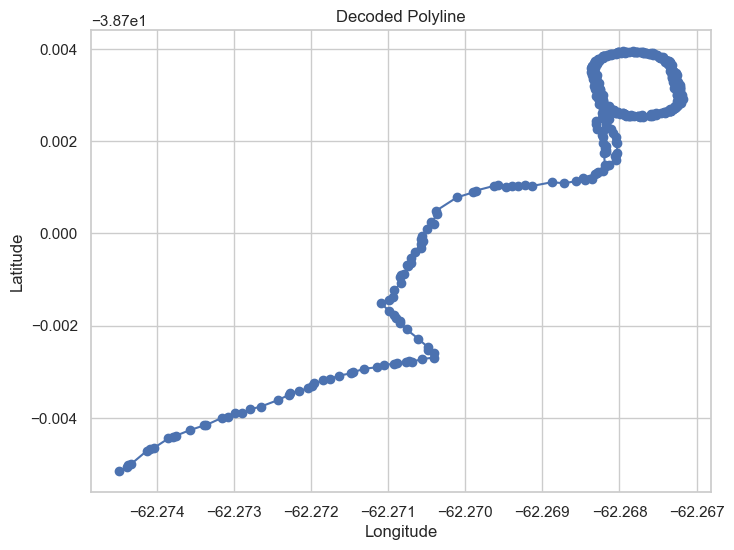

<class 'stravalib.model.Map'>
drfkFp~a{JeAo@e@s@g@i@W}@kB_DO_@o@_AWMG][a@C_@OWm@oDM_@MK_ARq@d@W@YXs@TUTcA_COq@QYMe@[y@OW]O_@s@Mq@]Eu@Hc@Rs@Ig@Yc@[]q@e@]MWB_@Em@IQi@o@q@c@e@M}APgAIoAHuAZY\Mj@Cd@J`@\Zb@H`AMz@Ab@KNOZ}@?e@Ug@SSaAEuBPg@^MZEf@Fh@PZXL\FjCQ\UVq@@k@Io@]YiB@oAPc@d@Qt@P|@^^`AAxBU`@g@L]?OEe@Ke@c@WoABQCMHeAJe@f@Mv@Lx@b@^VD~CW^[Ls@CeA_@_@[G_@HWCoBZa@ZK^Ab@J^P\b@XrD]LMPa@D_@?a@Ws@e@Yg@LuA@m@Pg@f@Gv@Tt@j@\~CG^[Z{@Ao@Qi@e@WaA@[JWCeAX[^Ip@Jn@T`@TLlDSd@i@Le@Cw@Yi@YSmA@_B\a@TMZCj@Pt@VXRDzA@`AMn@i@Hg@?]Qw@[UeAIYJUCQFEFi@Fg@f@Gd@?ZRj@PTb@NfD]\c@Hg@?QGg@Oa@m@S_ABqB^UXENA~@Tj@d@XZ@nCWd@a@J]QwA_@a@g@GiAD{@Je@TOVMn@Jl@LXd@`@l@@p@QfAGf@]Lk@?e@Kq@WSo@KkCT_@TYz@?RLr@\b@p@FpBWNDTKZa@H_@@g@Om@u@c@o@AyBZ]ZOt@Hp@d@n@~@D`AOn@?VINKJUHc@As@Ue@e@WaCFeA\Yl@A^Lv@`@b@pDGTKV[Lc@@YS_Ae@[c@CmBLe@PURSd@?x@Tb@XRXFfA?rASf@c@Hi@MgAa@e@}AAeARo@VWh@Ad@Jd@`@h@`@Hp@G@DhBYLGRYLy@Cg@GSc@_@]Gg@DyBZa@^IZ?RDj@LTTVZJj@@|@OVDl@MNQPe@Du@Km@MGEM]M}@?sB\e@b@It@Vv@h@ZRD^IzBE`@g@Ha@?g@Mm@][QEyABuAXSJS^Gl@Jf@\f@r@Xp@Bx@Xr@G`@WhBe@r

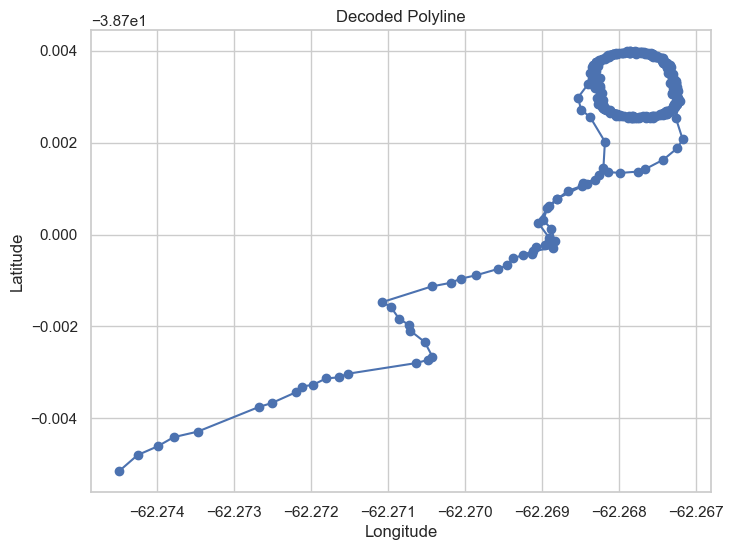

<class 'stravalib.model.Map'>
bsfkF|~a{Ju@c@iAiAa@Y]i@E[U]BGk@m@Ok@m@o@CMa@g@KWEC?Gq@o@Ec@KMY{@Ou@QkA?WKSASY]c@?GEOLa@Hy@r@k@RSPc@JEWe@aA?UIYe@_AKa@]c@@IMYBOKO?O]a@CYEGe@@c@Ze@LsAWo@c@c@s@[[]MQSI?OSYFa@EeAD_Aj@I?[PgAT_AHiAO}@_@W[K_@?Yb@kAPINSrAi@nBSdA@rARrAn@t@p@Lb@EXYN]AEEg@LgAF}Av@q@Tg@FiBK_@Kg@WSc@As@Z_A^YJMr@]d@KjAOd@Cl@@xAThAb@dAjABl@GJMHWMWPg@CgARKCc@`@u@TULk@HeA@o@Uo@Ig@_@I]D}@Pa@T[ROhBy@lBKbBH~An@bAbAVb@Ef@SHc@Ko@Ji@?{@VQPUDm@Zm@Dm@LsAKk@Ok@a@ESIE?MReAj@}@xB{@j@Kt@CbCV\Xt@Zb@VT^H^C\MLa@@KGSFMEy@D_Aj@K?QPa@Po@Pe@BmAG}@Ya@c@M_@?_@Fc@N]j@o@\O|Ae@LBXGDDRG|@?bALz@Vb@`@ZNDL^ZFXKn@m@CoAHa@JKPYDu@`@{AT}@@yA[_@c@G_@@w@^}@b@]bAc@dBSFE|@BXFDFX@TJj@FnAz@^j@@^IROJw@@a@EMHg@F{@h@_BX_@PaACu@Qo@]MUCy@@a@Vo@VYb@_@rAWZFxASv@FpA\fAh@j@|@Ad@MXaB?UL]@g@\q@VaC`@s@Iy@U_@WUq@Hu@Ng@b@g@d@OTQ~A[b@CDENFZAfALZPr@NtAjALf@ETGHuAJYA_@JgAl@K?{@XqALi@A}@Yg@WUo@CYFc@Xs@Z[ZSj@Qv@OjAGzBPzAj@^Z^h@DH@\UZa@AcAHs@Ps@b@{Bj@sAAc@Km@[SUMc@?e@DI@[Vk@X[d@U`B]jACHDrBPFEVNL@tAbAX^DRCPSVwBN}Bv@_AN_@Rm@DcASk@YY{@@aAXy@HANYPAr

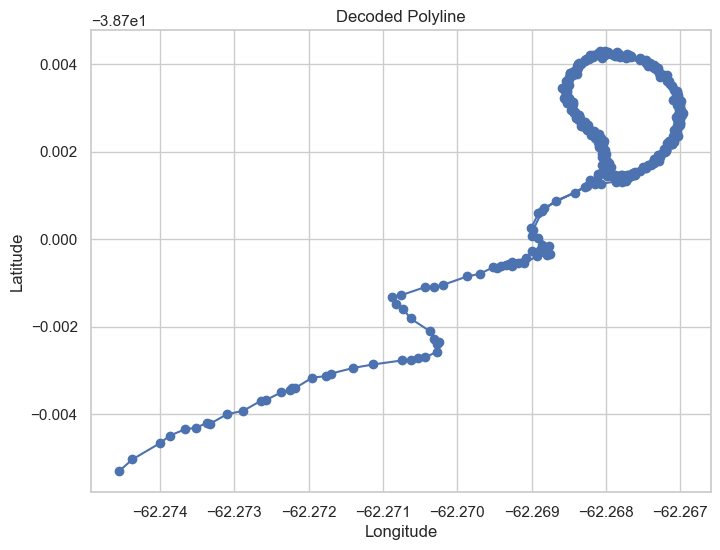

<class 'stravalib.model.Map'>
~rfkFd_b{JCKUAMMKCAIEEM?KIO[KIMECIUCCMEC?MCIGGMCCK@IIIGQOCEO?OEEI@D@Ki@OWAQKIMYSK@IGSGCEMIGOUYQDSSMU_@AWOO?MMYAQQOEKAEB]AWDEGO?IGQAGKS?GIKIAAOEEa@Ek@NE@?FOLW?ONE@OPYFMLWHCBAHGF_@@EHCAIg@IICGMk@M]?MICCQMW[kACQU_@AIEEISWWAGQ]]?ECg@V]Bm@Gc@UCGIEOGIIOo@QMG?QAUMIIa@Yu@Mu@NGICDIBEAGC_@T?JO@QJWBMN[AOHUBS?OFQAKBWG]Ao@Q]WW_@Am@Lm@Zm@ZSVIJQV?h@Uf@IT@ZCFDN\PJJZJDFZ@l@EVMLGPIFGAEFIAQH_@@IDW@MFCDW?KDUKi@[Gc@BWEI@_@Zg@VC@GFANBXKN@NIZ?d@OT@VFDLBLBFD\CLDNCz@KJa@PII[BEEOHQ@a@LMCUFYGUKQWES@GCa@DYJWFILGh@Ij@El@Qn@Bb@ZNf@B^GXYj@[JMCKFKACCi@Pu@Ha@IOIQ_@CWDOESDK@UNSRKP?FOVBz@Q\AHGLDP?RNNVFr@AXSj@]Pa@HSAKFc@B[LK?SIO?KKGKGGGI@QGOAIBK?YJOFQh@QDDJIx@EXIz@CRHJNFTDXEt@MNENQP_@Fc@CMFYDI@MCIFe@AWKQ_@AkAFWVUZBPOP?HGT@FE|@GJCRBHBFJBLFHDVBDI|@ELUZi@DEBg@BOFO@]J]?c@]KOG[?m@BQX]`@OR?XIL@LGR?HEF@JCLDTGPFVTDJ@f@In@MZQLc@LKC_BXi@CEIQMKSGQGo@FY^c@JEP?`AIF?DDJEJBj@Uj@LFHFP@z@EFANMVAFa@VKAMFs@Bo@Ro@GSMIQMe@@GC[H_@HMLK|@MLIFBVKJ@HEJ?p@GNFPBHRH`@AV@TQh@MPIDaBPCF_AFc@GMKOWAYHcAT[H?NI`@Cf@MH@VKJBJEPC

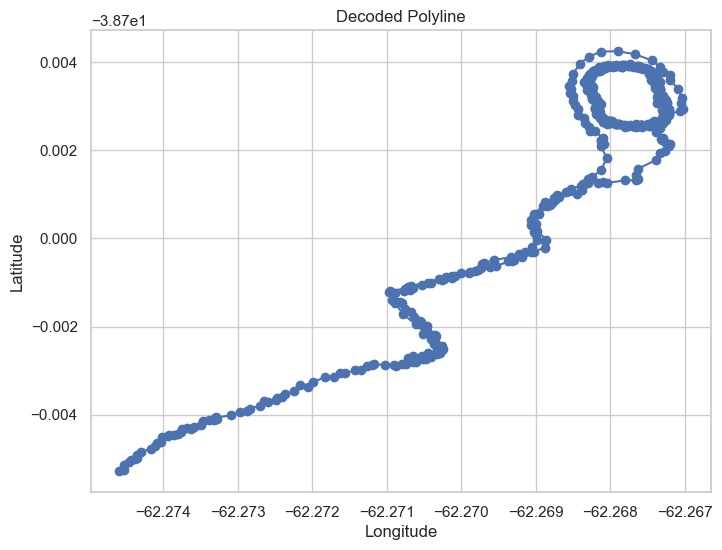

<class 'stravalib.model.Map'>
nofkFh|a{Jm@u@CWQQw@{ACS]i@AMgA_BCKk@k@a@o@M_@BOYq@Ac@KQIe@McA]w@yAJINi@Pc@^aA\gAPYIYWU?aA]_Cg@o@Ga@c@_@w@WgAQoAAy@Wu@Qe@y@u@yAI_@McAeAIe@GIUQ_@I[AyALs@R]\Iz@Db@`@j@d@L|BKr@[Tg@Bq@GY@KMYUMu@KwAJiAZQVKl@Hn@HRX^ZFfAGb@D`@Gh@WXe@Bk@Ai@K]OOa@O]Ay@NcAH_@NUTGTGl@F`@T`@ZVNBdAOZBx@Ib@UXs@Bu@CYk@c@i@Ke@?kALw@TQNO`@ARFj@Nb@d@^nCGt@ULOPi@BYEi@IWSUw@So@@{B\Yl@El@Jj@JRd@^dBApAOZYLWFa@?k@IU][q@UmAF}AXWXI\?v@b@t@^Nl@@dBOb@IXUTe@?o@Ka@MS}@[y@AkBVQLYn@?~@P^\\z@FjCUf@w@DW?a@Su@k@Ys@EaADaAZO@SZIXCZDb@Xn@t@RfBUb@@`@K\g@Ju@AUUg@a@Wm@MeCTg@TUf@C`@Fd@^v@VFtBGrAQ^k@DeAI[m@e@k@KmAJSEoAh@MTKj@N|@R`@TJV@~@KVDd@MNBh@QT_@FYBs@Oa@q@e@g@GmCZSHW^Cp@Jv@LVRN`BBdBU`@YNa@B[Cc@O[q@c@k@IaCVo@f@Md@Bd@JXVb@\RZBv@ONFx@Gd@OLKPk@BaAGSQWm@[q@?iBP}@h@G|@B`@L^j@`@b@@bCQl@a@P_@D_@Am@CG}@m@_AEsBZOFW^K\?\Nn@V\PF~BE~@Mf@q@Di@Aa@]i@eA[o@Lm@?]N]D[ZI`@C`@H`@V^l@XpCOZINKR_@JaAWw@u@YyBFs@LSJOVIXAX@ZPf@RXXJhAKj@DhAUZc@N{@Oq@i@e@qB@uATa@\ELEb@Hn@Vb@h@TvBI|@QRORa@@i@Ec@]e@g@OuBBeAV]^Eh@Bd@Pb@TVt@Jn@l@lBKZUXEFFXYT

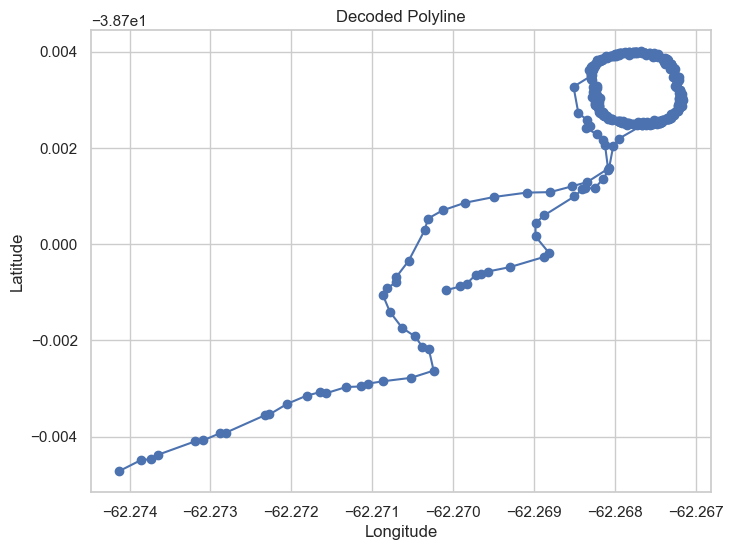

<class 'stravalib.model.Map'>
vpfkFt}a{JICo@u@MGC[M[IEGKCCk@u@QKE?@SEUWa@@GAGOMWe@QOAG_@_@EUIIM[QIAUEG@EKQESM]?MIK@GKc@BUEG?MIKAMCE@GIKAGECKa@IQ[GMBKCa@P[X_@PIHYHIHKFGJk@LIQMOG[EEEu@MSAQKIEQIKQMAGSYM]ECGOOKKYII@GCGMM?Wk@GIHO@IFW?a@FSCMGOAq@m@WMCG?OCEWWICGSKOIGKCe@@MAIBKEkAJg@Ja@TKBGDg@NOAEDODQ@YF]BEBM@SIe@IMIG?g@a@Oy@Hi@Xs@\[PEFMNEFEr@QB@JEJ?TCPDPEJ@DCHD^GHFJAh@J`@LP?\LRR\RDHFDHJN`@@RADOTMDOEEBQAs@LEA]HI?SFOLk@TCDYBUHCDSBY?EHEAMBm@Aw@O[S]a@EK?GEM?KBc@Ni@BMHGLWPSTAHGPEDEVEDGJ@DCXEz@ATDDCB@^CDDb@?JFJLJ@PJV?j@Xn@p@NZ?^GJUJQAWHq@?a@DEBYHIJKBMLi@NIF{@JKDEAWBYCa@@UEYMMA]YSm@A_@VaARQLUp@_@PQL?RIP@ZAb@INDJGTDFAV@DAXLj@BBHPDL?HFD?NFVPNVXRTj@CRORe@DSCOD]AKDa@DSJe@\YFOJK?a@PY@ODq@Bi@ICEq@Oe@]O]Ie@D]Le@JKlCmAd@EBE~@?NDr@ETFJFDAPBLH^FDFJ?HFNDf@b@D@R`@Hb@CFIFWFO?KBECw@@KFs@PGHKBSNe@NK@OHOBKAKF[@q@JQEE@QII@UOQCYQAGMGM_@@g@JSDUDKDCLW\[TIBE^INKLAFGb@?PEh@@NCPBXCBDF?JAPHP?XNNABDXJNH@FJDVTNFXZD`@AFKNIDKBQGYHKCs@Ba@VAHM?OFWLCDQDKA_@LOAKDI@IDy@D[?WGIE]Gi@WKWGe@@SF]JM?INSv@q@l@UJ?PENIJ?LEJBHG\@ZAjBTLHP?FDJ@

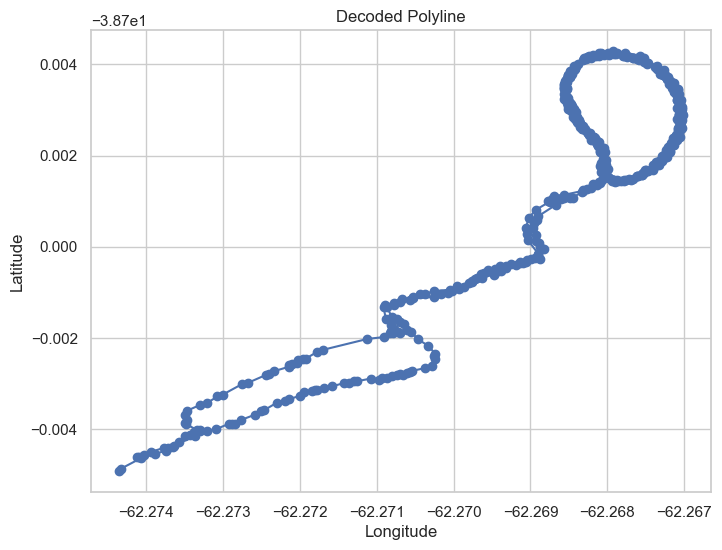

In [13]:
import polyline

for i, activity in enumerate(activities):
    print(type(activity.map))
    # show map
    print(activity.map.summary_polyline)
    # decode via google polyline algorithm
    
    decoded_coordinates = polyline.decode(activity.map.summary_polyline)

    # Separate latitudes and longitudes for plotting
    latitudes = [coord[0] for coord in decoded_coordinates]
    longitudes = [coord[1] for coord in decoded_coordinates]

    plt.figure(figsize=(8, 6))
    plt.plot(longitudes, latitudes, marker='o', linestyle='-')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Decoded Polyline')
    plt.grid(True)
    plt.show()